Cargando y procesando datos para análisis de traslación...

Resultados del ajuste por mínimos cuadrados:
mu_x_lin = 2.472284 (calculado del tramo de mayor velocidad lineal)
mu_y_lin = -0.172186 (calculado del tramo donde velocidad lineal y angular son similares)

Evaluación en datos de validación:
MSE en x: 0.202925
MSE en y: 0.307788
Análisis de traslación completado.


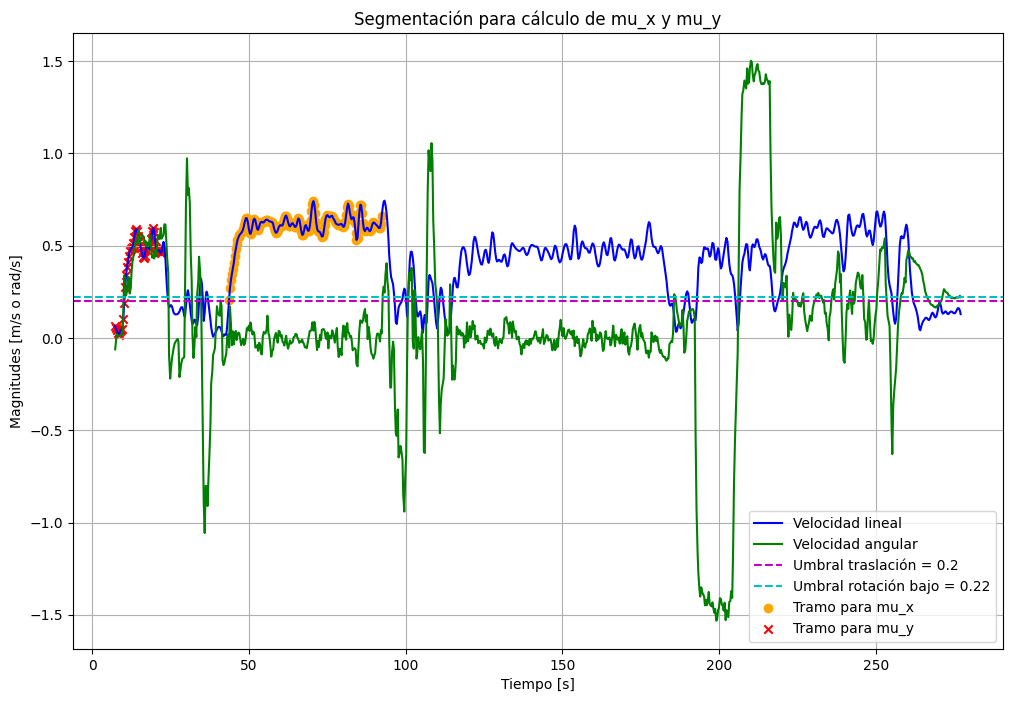

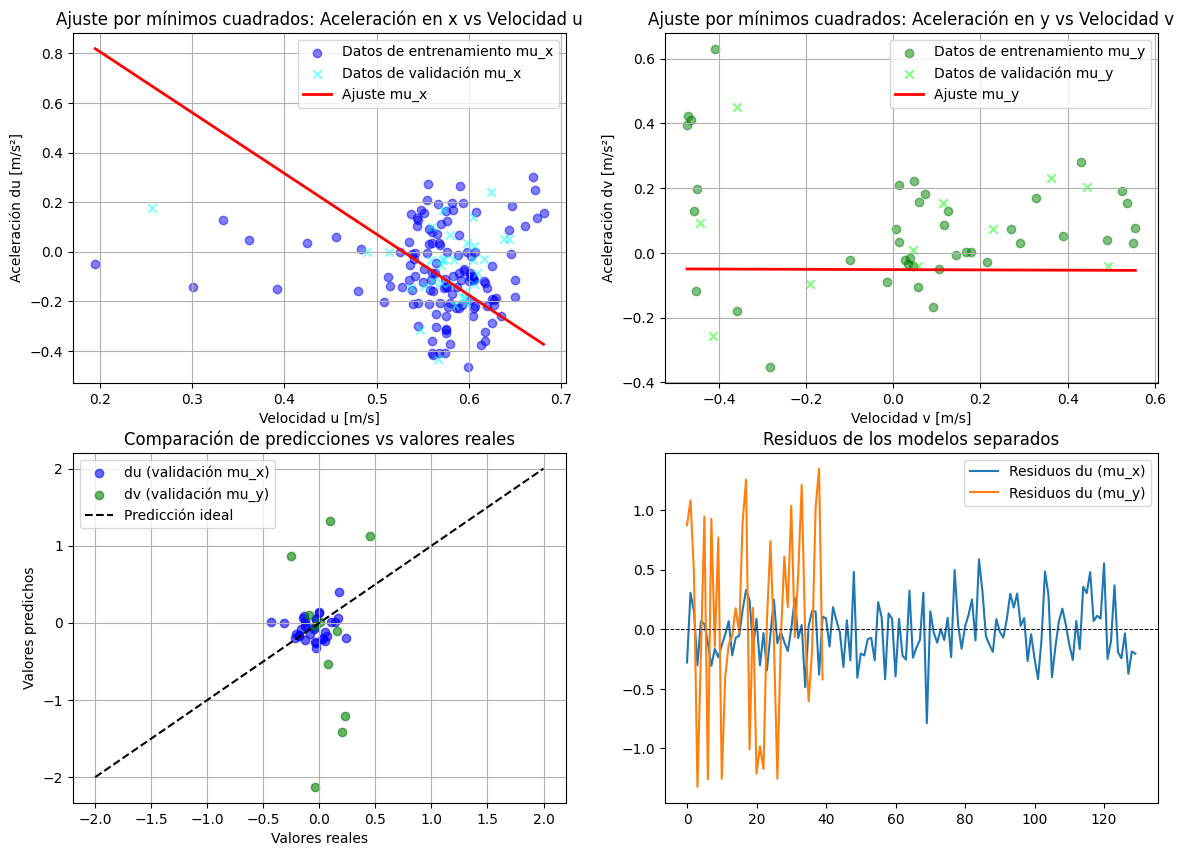

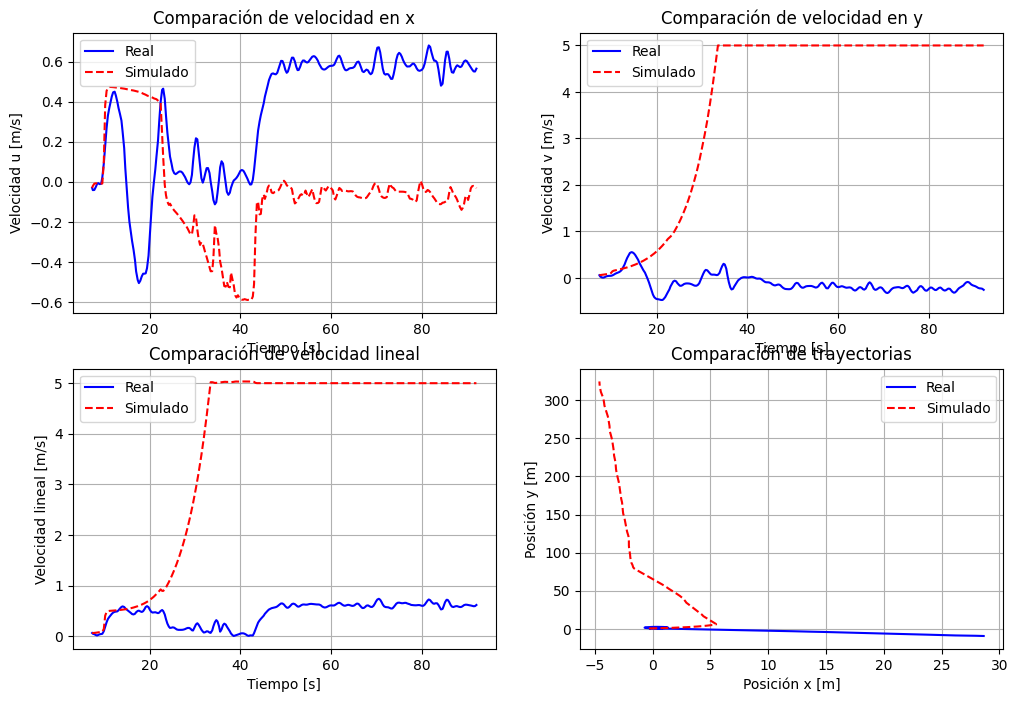

In [1]:
"""
Análisis de rozamiento de traslación para vehículo marino

Este script se enfoca exclusivamente en el análisis del rozamiento de traslación,
separado del análisis de rotación. Se han implementado ajustes independientes para
los coeficientes mu_x y mu_y, utilizando tramos de datos diferentes para cada uno.
"""

import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.optimize import least_squares
from scipy.signal import butter, filtfilt
from scipy.signal import savgol_filter

# Funciones auxiliares
def extraccion_datos(var, pos):
    """
    Extrae datos de un archivo de registro.
    
    Args:
        var: Variable a extraer
        pos: Posición de la variable en la línea
    
    Returns:
        Tupla con los datos extraídos y sus tiempos correspondientes
    """
    home_dir = os.path.expanduser("~")
    ruta_datos = os.path.join(home_dir, "paparazzi", "var", "logs", "25_05_28__16_27_03.data")
    
    dato = []
    tiempo = []
    with open(ruta_datos, "r", encoding="utf-8") as file:
        for line in file:
            if var in line:
                campos = line.strip().split()
                if campos[2] == var:
                    dato.append(float(campos[pos]))
                    tiempo.append(float(campos[0]))
    return np.array(dato), np.array(tiempo)


def filtrado_tiempo_comun(t_comun, dt_min=0.1, dt_max=1):
    """
    Filtra los tiempos para obtener intervalos regulares.
    
    Args:
        t_comun: Array de tiempos a filtrar
        dt_min: Intervalo mínimo entre muestras
        dt_max: Intervalo máximo entre muestras
    
    Returns:
        Tiempos filtrados e índices correspondientes
    """
    dt = np.gradient(t_comun)
    mask = (dt >= dt_min) & (dt <= dt_max)
    mask[0] = True
    indices = np.where(mask)[0]
    t_filtrado = t_comun[indices]
    
    return t_filtrado, indices


def interp_to_common(t_original, data_original, t_comun):
    """
    Interpola datos a una base de tiempo común.
    
    Args:
        t_original: Tiempos originales
        data_original: Datos originales
        t_comun: Base de tiempo común para interpolación
    
    Returns:
        Datos interpolados
    """
    interp_func = interp1d(t_original, data_original, kind='linear', bounds_error=False, fill_value="extrapolate")
    return interp_func(t_comun)

def normalize_angle(angle):
    """
    Normaliza un ángulo al rango [-π, π].
    
    Args:
        angle: Ángulo a normalizar
        
    Returns:
        Ángulo normalizado
    """
    return ((angle + np.pi) % (2 * np.pi)) - np.pi

def filtro_butterworth(data, cutoff_freq, fs, order=4):
    """
    Aplica un filtro Butterworth pasa-bajos.
    
    Args:
        data: Datos a filtrar
        cutoff_freq: Frecuencia de corte (Hz)
        fs: Frecuencia de muestreo (Hz)
        order: Orden del filtro
        
    Returns:
        Datos filtrados
    """
    nyquist = 0.5 * fs
    normal_cutoff = cutoff_freq / nyquist
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    y = filtfilt(b, a, data)
    return y

def limit_velocity(velocity, max_vel=5.0):
    """
    Limita la velocidad a un valor máximo físicamente razonable.
    
    Args:
        velocity: Valor de velocidad a limitar
        max_vel: Velocidad máxima permitida en m/s
        
    Returns:
        Velocidad limitada al rango [-max_vel, max_vel]
    """
    return np.clip(velocity, -max_vel, max_vel)

def tramo_minima_dependencia(indices, v_lineal, omega_abs, tipo='traslacion', min_length=10):
    """
    Selecciona el tramo continuo que minimiza la dependencia cruzada.
    
    Args:
        indices: Array de índices a analizar
        v_lineal: Array de velocidades lineales
        omega_abs: Array de velocidades angulares absolutas
        tipo: 'traslacion' o 'rotacion', indica el tipo de tramo a seleccionar
        min_length: Longitud mínima que debe tener un segmento para ser considerado
        
    Returns:
        Array con el segmento que minimiza la dependencia cruzada
    """
    if len(indices) == 0:
        return indices
    
    # Detecta rupturas de continuidad
    cortes = np.where(np.diff(indices) != 1)[0] + 1
    segmentos = np.split(indices, cortes)
    
    # Filtra segmentos de al menos longitud mínima
    segmentos_validos = [seg for seg in segmentos if len(seg) >= min_length]
    
    if not segmentos_validos:
        return np.array([], dtype=int)
    
    # Calcula la métrica de dependencia para cada segmento
    if tipo == 'traslacion':
        # Para traslación, queremos minimizar la velocidad angular
        metricas = [np.mean(omega_abs[seg]) for seg in segmentos_validos]
        # Normalizar por la velocidad lineal para favorecer segmentos con alta velocidad lineal
        metricas_normalizadas = [metricas[i] / (np.mean(v_lineal[seg]) + 1e-6) 
                               for i, seg in enumerate(segmentos_validos)]
        # Seleccionar el segmento con la menor métrica normalizada
        mejor_segmento = segmentos_validos[np.argmin(metricas_normalizadas)]
        
    elif tipo == 'rotacion':
        # Para rotación, queremos minimizar la velocidad lineal
        metricas = [np.mean(v_lineal[seg]) for seg in segmentos_validos]
        # Normalizar por la velocidad angular para favorecer segmentos con alta velocidad angular
        metricas_normalizadas = [metricas[i] / (np.mean(omega_abs[seg]) + 1e-6) 
                               for i, seg in enumerate(segmentos_validos)]
        # Seleccionar el segmento con la menor métrica normalizada
        mejor_segmento = segmentos_validos[np.argmin(metricas_normalizadas)]
    
    return mejor_segmento
    
from scipy.stats import pearsonr

def tramo_mayor_correlacion(indices, v_lineal, omega_abs):
    """
    Selecciona el tramo donde la velocidad lineal y angular están más correlacionadas.
    
    Args:
        indices: array de índices válidos
        v_lineal: array de velocidades lineales
        omega_abs: array de velocidades angulares absolutas
        
    Returns:
        Array con los índices del mejor segmento
    """
    if len(indices) == 0:
        return indices
        
    cortes = np.where(np.diff(indices) != 1)[0] + 1
    segmentos = np.split(indices, cortes)
    segmentos_largos = [seg for seg in segmentos if len(seg) > 1]

    correlaciones = [
        pearsonr(v_lineal[seg], omega_abs[seg])[0] if len(seg) > 2 else 0
        for seg in segmentos_largos
    ]
    
    # Seleccionar el segmento con mayor correlación positiva
    mejor_segmento = segmentos_largos[np.argmax(correlaciones)]
    return mejor_segmento

def tramo_mas_largo(indices):
    """
    Devuelve el sub-array continuo más largo dentro de `indices`.
    
    Args:
        indices: Array de índices a analizar
        
    Returns:
        Array con el segmento continuo más largo
    """
    if len(indices) == 0:
        return indices
    # detecta rupturas de continuidad
    cortes = np.where(np.diff(indices) != 1)[0] + 1
    segmentos = np.split(indices, cortes)
    # filtra segmentos de al menos longitud 2
    segmentos_largos = [seg for seg in segmentos if len(seg) > 1]
    if not segmentos_largos:
        return np.array([], dtype=int)
    # devuelve el más largo
    return max(segmentos_largos, key=len)

def tramo_mayor_velocidad(indices, velocidad):
    """
    Devuelve, dentro de los segmentos continuos en `indices`,
    aquel cuya velocidad (en el array `velocidad`) alcance el valor máximo.
    
    Args:
        indices: Array de índices a analizar
        velocidad: Array de velocidades correspondientes
        
    Returns:
        Array con el segmento que contiene la mayor velocidad
    """
    if len(indices) == 0:
        return indices
    cortes = np.where(np.diff(indices) != 1)[0] + 1
    segmentos = np.split(indices, cortes)
    segmentos_largos = [seg for seg in segmentos if len(seg) > 1]
    if not segmentos_largos:
        return np.array([], dtype=int)
    # selecciona el segmento con mayor pico de velocidad
    return max(segmentos_largos, key=lambda seg: np.max(velocidad[seg]))

def tramo_similar_velocidad_lineal_angular(indices, v_lineal, omega_abs, rango_tiempo=(0, 50)):
    """
    Selecciona el tramo donde la velocidad lineal y angular son similares,
    dentro del rango de tiempo especificado.
    
    Args:
        indices: Array de índices a analizar
        v_lineal: Array de velocidades lineales
        omega_abs: Array de velocidades angulares absolutas
        rango_tiempo: Tupla con (tiempo_inicio, tiempo_fin) para buscar el tramo
        
    Returns:
        Array con el segmento donde velocidad lineal y angular son similares
    """
    if len(indices) == 0:
        return indices
    
    # Filtrar índices dentro del rango de tiempo especificado
    indices_en_rango = [i for i in indices if rango_tiempo[0] <= i <= rango_tiempo[1]]
    
    if not indices_en_rango:
        return np.array([], dtype=int)
    
    # Detecta rupturas de continuidad
    cortes = np.where(np.diff(indices_en_rango) != 1)[0] + 1
    segmentos = np.split(indices_en_rango, cortes)
    
    # Filtra segmentos de al menos longitud 10
    segmentos_largos = [seg for seg in segmentos if len(seg) >= 10]
    
    if not segmentos_largos:
        return np.array([], dtype=int)
    
    # Calcula la diferencia entre velocidad lineal y angular para cada segmento
    metricas = []
    for seg in segmentos_largos:
        v_lin_media = np.mean(v_lineal[seg])
        omega_media = np.mean(np.abs(omega_abs[seg]))
        # Métrica: diferencia relativa entre velocidad lineal y angular
        diferencia_relativa = np.abs(v_lin_media - omega_media) / (v_lin_media + omega_media + 1e-6)
        metricas.append(diferencia_relativa)
    
    # Seleccionar el segmento con la menor diferencia relativa
    mejor_segmento = segmentos_largos[np.argmin(metricas)]
    return mejor_segmento

def split_train_validation(indices, train_ratio=0.8):
    """
    Divide los índices en conjuntos de entrenamiento y validación.
    
    Args:
        indices: Array de índices a dividir
        train_ratio: Proporción para el conjunto de entrenamiento (0-1)
        
    Returns:
        Tupla con (índices_entrenamiento, índices_validación)
    """
    n = len(indices)
    n_train = int(train_ratio * n)
    # Aseguramos que la división sea aleatoria pero reproducible
    np.random.seed(42)
    indices_shuffled = np.random.permutation(indices)
    train_indices = indices_shuffled[:n_train]
    valid_indices = indices_shuffled[n_train:]
    return train_indices, valid_indices

# Función para el cálculo de residuos solo para mu_x
def residuals_trans_lineal_mu_x(params):
    """
    Función de residuos para el movimiento de traslación.
    Incluye solo términos lineales de fricción para mu_x, manteniendo mu_y fijo en 0.
    
    Args:
        params: [mu_x_lin]
            mu_x_lin: Coeficiente de fricción lineal en x
    """
    mu_x_lin = params[0]
    mu_y_lin = 0  # Fijamos mu_y en 0 para este ajuste
    
    a = np.cos(orientacion_trans_x)
    b = np.sin(orientacion_trans_x)
    
    # Términos lineales
    term1_x_lin = (a**2)*mu_x_lin*u_trans_smooth_x
    term2_x_lin = (b**2)*mu_y_lin*u_trans_smooth_x
    term3_x_lin = a*b*v_trans_smooth_x*(mu_x_lin - mu_y_lin)
    
    # Residuos en x
    res_x = du_trans_smooth_x - (fa_trans_x * a - (term1_x_lin + term2_x_lin + term3_x_lin))

    # Términos lineales
    term1_y_lin = (b**2)*mu_x_lin*v_trans_smooth_x
    term2_y_lin = (a**2)*mu_y_lin*v_trans_smooth_x
    term3_y_lin = a*b*u_trans_smooth_x*(mu_x_lin - mu_y_lin)
    
    # Residuos en y
    res_y = dv_trans_smooth_x - (fa_trans_x * b - (term1_y_lin + term2_y_lin + term3_y_lin))

    # Asegurar que los residuos sean finitos
    res_x = np.where(np.isfinite(res_x), res_x, 0.0)
    res_y = np.where(np.isfinite(res_y), res_y, 0.0)

    return np.concatenate((res_x, res_y))

# Función para el cálculo de residuos solo para mu_y
def residuals_trans_lineal_mu_y(params):
    """
    Función de residuos para el movimiento de traslación.
    Incluye solo términos lineales de fricción para mu_y, manteniendo mu_x fijo en 0.
    
    Args:
        params: [mu_y_lin]
            mu_y_lin: Coeficiente de fricción lineal en y
    """
    mu_x_lin = 0  # Fijamos mu_x en 0 para este ajuste
    mu_y_lin = params[0]
    
    a = np.cos(orientacion_trans_y)
    b = np.sin(orientacion_trans_y)
    
    # Términos lineales
    term1_x_lin = (a**2)*mu_x_lin*u_trans_smooth_y
    term2_x_lin = (b**2)*mu_y_lin*u_trans_smooth_y
    term3_x_lin = a*b*v_trans_smooth_y*(mu_x_lin - mu_y_lin)
    
    # Residuos en x
    res_x = du_trans_smooth_y - (fa_trans_y * a - (term1_x_lin + term2_x_lin + term3_x_lin))

    # Términos lineales
    term1_y_lin = (b**2)*mu_x_lin*v_trans_smooth_y
    term2_y_lin = (a**2)*mu_y_lin*v_trans_smooth_y
    term3_y_lin = a*b*u_trans_smooth_y*(mu_x_lin - mu_y_lin)
    
    # Residuos en y
    res_y = dv_trans_smooth_y - (fa_trans_y * b - (term1_y_lin + term2_y_lin + term3_y_lin))

    # Asegurar que los residuos sean finitos
    res_x = np.where(np.isfinite(res_x), res_x, 0.0)
    res_y = np.where(np.isfinite(res_y), res_y, 0.0)

    return np.concatenate((res_x, res_y))

def evaluate_model_trans_lineal(params, indices):
    """
    Evalúa el modelo de traslación lineal en los índices dados.
    
    Args:
        params: Parámetros del modelo [mu_x_lin, mu_y_lin]
        indices: Índices donde evaluar el modelo
        
    Returns:
        Tupla con (du_pred, dv_pred, mse_x, mse_y)
    """
    u_eval = u_i[indices]
    v_eval = v_i[indices]
    du_eval = du[indices]
    dv_eval = dv[indices]
    fa_eval = T_L[indices] + T_R[indices]
    orientacion_eval = orientacion_i[indices]
    
    mu_x_lin = params[0]
    mu_y_lin = params[1]
    
    a = np.cos(orientacion_eval)
    b = np.sin(orientacion_eval)
    
    # Términos lineales
    term1_x_lin = (a**2)*mu_x_lin*u_eval
    term2_x_lin = (b**2)*mu_y_lin*u_eval
    term3_x_lin = a*b*v_eval*(mu_x_lin - mu_y_lin)
    
    # Aceleración predicha en x con protección contra desbordamiento
    du_pred = fa_eval * a - (term1_x_lin + term2_x_lin + term3_x_lin)
    
    # Términos lineales
    term1_y_lin = (b**2)*mu_x_lin*v_eval
    term2_y_lin = (a**2)*mu_y_lin*v_eval
    term3_y_lin = a*b*u_eval*(mu_x_lin - mu_y_lin)
    
    # Aceleración predicha en y con protección contra desbordamiento
    dv_pred = fa_eval * b - (term1_y_lin + term2_y_lin + term3_y_lin)
    
    # Asegurar que las predicciones sean finitas
    du_pred = np.where(np.isfinite(du_pred), du_pred, 0.0)
    dv_pred = np.where(np.isfinite(dv_pred), dv_pred, 0.0)
    
    # Error cuadrático medio
    mse_x = np.mean((du_eval - du_pred)**2)
    mse_y = np.mean((dv_eval - dv_pred)**2)
    
    return du_pred, dv_pred, mse_x, mse_y

def simulate_motion_traslacion(t_sim, u0, v0, theta0, fa_sim, params_trans):
    """
    Simula el movimiento de traslación del vehículo.
    
    Args:
        t_sim: Array de tiempos para la simulación
        u0: Velocidad inicial en x
        v0: Velocidad inicial en y
        theta0: Orientación inicial
        fa_sim: Array de fuerzas de propulsión
        params_trans: Parámetros del modelo de traslación [mu_x_lin, mu_y_lin]
        
    Returns:
        Tupla con (u_sim, v_sim, theta_sim)
    """
    dt = np.diff(t_sim)
    n = len(t_sim)

    u_sim = np.zeros(n)
    v_sim = np.zeros(n)
    theta_sim = np.zeros(n)

    max_vel_lineal = 5.0  # m/s

    u_sim[0] = limit_velocity(u0, max_vel_lineal)
    v_sim[0] = limit_velocity(v0, max_vel_lineal)
    theta_sim[0] = theta0

    mu_x_lin = params_trans[0]
    mu_y_lin = params_trans[1]
    
    for i in range(1, n):
        u_prev = u_sim[i-1]
        v_prev = v_sim[i-1]
        theta_prev = theta_sim[i-1]

        a = np.cos(theta_prev)
        b = np.sin(theta_prev)

        # TÉRMINOS DE TRASLACIÓN
        term1_x_lin = a * a * mu_x_lin * u_prev
        term2_x_lin = b * b * mu_y_lin * u_prev
        term3_x_lin = a * b * (mu_x_lin - mu_y_lin) * v_prev
        friction_x = term1_x_lin + term2_x_lin + term3_x_lin
        propulsion_x = fa_sim[i-1] * a
        du_sim = propulsion_x - friction_x

        term1_y_lin = b * b * mu_x_lin * v_prev
        term2_y_lin = a * a * mu_y_lin * v_prev
        term3_y_lin = a * b * (mu_x_lin - mu_y_lin) * u_prev
        friction_y = term1_y_lin + term2_y_lin + term3_y_lin
        propulsion_y = fa_sim[i-1] * b
        dv_sim = propulsion_y - friction_y

        u_next = u_prev + du_sim * dt[i-1]
        v_next = v_prev + dv_sim * dt[i-1]

        u_sim[i] = limit_velocity(u_next, max_vel_lineal)
        v_sim[i] = limit_velocity(v_next, max_vel_lineal)
        theta_sim[i] = theta_prev  # La orientación se mantiene constante en este modelo simplificado

        u_sim[i] = 0.0 if not np.isfinite(u_sim[i]) else u_sim[i]
        v_sim[i] = 0.0 if not np.isfinite(v_sim[i]) else v_sim[i]

    return u_sim, v_sim, theta_sim

def analizar_traslacion():
    """
    Función principal para ejecutar el análisis de traslación con ajustes separados para mu_x y mu_y,
    utilizando tramos de datos diferentes para cada uno.
    """
    global u_i, v_i, du, dv, T_L, T_R, orientacion_i, v_lineal, omega_abs
    global indices_trans_train_x, indices_trans_valid_x, indices_trans_train_y, indices_trans_valid_y
    global u_trans_smooth_x, v_trans_smooth_x, du_trans_smooth_x, dv_trans_smooth_x, fa_trans_x, orientacion_trans_x
    global u_trans_smooth_y, v_trans_smooth_y, du_trans_smooth_y, dv_trans_smooth_y, fa_trans_y, orientacion_trans_y
    
    # Cargar y procesar datos
    print("Cargando y procesando datos para análisis de traslación...")
    
    # Extracción de datos
    escala_vel = 0.0000019
    u_raw, t_u = extraccion_datos("INS", 6)
    v_raw, t_v = extraccion_datos("INS", 7)

    # Aplicamos la transformación a las velocidades
    u_escalado_original = u_raw * escala_vel  # Velocidad en x original (derecha)
    v_escalado_original = v_raw * escala_vel  # Velocidad en y original (adelante)

    # Transformamos al sistema del modelo
    u_escalado = u_escalado_original  
    v_escalado = v_escalado_original 

    # Aplicamos la misma transformación a las aceleraciones
    escala_acc = 0.0009766
    du_raw, t_du = extraccion_datos("INS", 9)
    dv_raw, t_dv = extraccion_datos("INS", 10)

    du_scaled_original = du_raw * escala_acc  
    dv_scaled_original = dv_raw * escala_acc 

    # Transformamos al sistema del modelo
    du_scaled = du_scaled_original 
    dv_scaled = dv_scaled_original  

    orientacion_raw, t_orientacion = extraccion_datos("ATTITUDE", 4)
    w_raw, t_w = extraccion_datos("BODY_RATES_ACCEL", 5)
    throttle_L, t_T_L = extraccion_datos("BOAT_CTRL", 7)
    throttle_R, t_T_R = extraccion_datos("BOAT_CTRL", 8)
    throttle_L_norm = throttle_L / 9600
    throttle_R_norm = throttle_R / 9600

    # Parámetros físicos del barco
    masa_barco = 50  # kg
    distancia_motores = 0.75/2  # m

    orientacion_corregida = orientacion_raw
    # Aplicamos el ajuste para el nuevo sistema de coordenadas
    orientacion_unwrapped = np.unwrap(orientacion_corregida)

    t_comun = t_u
    # MEJORA: Ajuste del umbral de filtrado para obtener datos más consistentes
    t_filtrado, indices_filtrado = filtrado_tiempo_comun(t_comun, dt_min=0.2, dt_max=0.6)

    # Calcular frecuencia de muestreo promedio para filtrado
    fs = 1.0 / np.mean(np.diff(t_filtrado))
    cutoff_freq = 0.5  # Hz, ajustar según las características de la señal
    orientacion_filtered = -filtro_butterworth(orientacion_unwrapped, cutoff_freq, fs)

    # Interpolación
    u_interp = interp_to_common(t_u, u_escalado, t_filtrado)
    v_interp = interp_to_common(t_v, v_escalado, t_filtrado)
    du_interp = interp_to_common(t_du, du_scaled, t_filtrado)
    dv_interp = interp_to_common(t_dv, dv_scaled, t_filtrado)
    # Interpolar los datos de orientación ya desenrollados y filtrados
    orientacion_i = interp_to_common(t_orientacion, orientacion_filtered, t_filtrado)
    w_i = interp_to_common(t_w, w_raw, t_filtrado)
    throttle_L_i = interp_to_common(t_T_L, throttle_L_norm, t_filtrado)
    throttle_R_i = interp_to_common(t_T_R, throttle_R_norm, t_filtrado)

    # MEJORA: Filtrado de señales para reducir ruido
    u_i = filtro_butterworth(u_interp, cutoff_freq, fs)
    v_i = filtro_butterworth(v_interp, cutoff_freq, fs)

    # Cálculo fuerzas motoras (modelo simplificado)
    # NOTA: Este modelo polinómico debería ser calibrado específicamente para los motores del barco
    T_L = (2.4277*(throttle_L_i)**3 + 0.4041*(throttle_L_i)**2 + 0.9662*throttle_L_i - 0.0004)*9.8/masa_barco
    T_R = (2.4277*(throttle_R_i)**3 + 0.4041*(throttle_R_i)**2 + 0.9662*throttle_R_i - 0.0004)*9.8/masa_barco
    
    # MEJORA: Unificación del método de cálculo de derivadas usando np.gradient
    # Cálculo de derivadas temporales usando np.gradient para mayor consistencia
    dt_array = np.gradient(t_filtrado)
    r = w_i  # omega
    dr = np.gradient(w_i) / dt_array  # alpha
    du = du_scaled
    dv = dv_scaled

    # Magnitudes de movimiento
    v_lineal = np.sqrt(u_i**2 + v_i**2)
    omega_abs = r

    # Definición de umbrales para segmentación
    umbral_traslacion = 0.2  # Umbral para movimientos de traslación
    umbral_rotacion_bajo = 0.22  # Umbral más bajo para detectar inicio de rotación
    
    # MEJORA: Segmentación mejorada con criterios más estrictos
    # Máscara para traslación: velocidad lineal alta Y velocidad angular muy baja
    mask_activo_traslacion = (v_lineal > umbral_traslacion) & (omega_abs < umbral_rotacion_bajo)

    # Segmentación con umbrales separados y condiciones adicionales
    indices_trans = np.where(mask_activo_traslacion)[0]

    # Visualización de la segmentación y selección de tramos
    plt.figure(figsize=(12, 8))
    plt.plot(t_filtrado, v_lineal, 'b-', label='Velocidad lineal')
    plt.plot(t_filtrado, omega_abs, 'g-', label='Velocidad angular')
    plt.axhline(y=umbral_traslacion, color='m', linestyle='--', label=f'Umbral traslación = {umbral_traslacion}')
    plt.axhline(y=umbral_rotacion_bajo, color='c', linestyle='--', label=f'Umbral rotación bajo = {umbral_rotacion_bajo}')
    
    # Tramo para mu_x: segmento de mayor velocidad lineal
    indices_trans_x = tramo_mayor_velocidad(indices_trans, v_lineal)
    
    # Tramo para mu_y: primer tramo donde velocidad lineal y angular son similares
    indices_trans_y = tramo_similar_velocidad_lineal_angular(np.arange(len(t_filtrado)), v_lineal, omega_abs, rango_tiempo=(0, 50))
    
    # Marcar los tramos seleccionados en la gráfica
    plt.scatter(t_filtrado[indices_trans_x], v_lineal[indices_trans_x], color='orange', marker='o', label='Tramo para mu_x')
    plt.scatter(t_filtrado[indices_trans_y], v_lineal[indices_trans_y], color='red', marker='x', label='Tramo para mu_y')
    
    plt.xlabel('Tiempo [s]')
    plt.ylabel('Magnitudes [m/s o rad/s]')
    plt.title('Segmentación para cálculo de mu_x y mu_y')
    plt.legend()
    plt.grid(True)

    # Dividimos los datos para validación cruzada (tramo mu_x)
    indices_trans_train_x, indices_trans_valid_x = split_train_validation(indices_trans_x)

    # Segmentos de datos para traslación (entrenamiento) - mu_x
    u_trans_x = u_i[indices_trans_train_x]
    v_trans_x = v_i[indices_trans_train_x]
    du_trans_x = du[indices_trans_train_x]
    dv_trans_x = dv[indices_trans_train_x]
    fa_trans_x = T_L[indices_trans_train_x] + T_R[indices_trans_train_x]
    orientacion_trans_x = orientacion_i[indices_trans_train_x]

    # Sin filtrar - mu_x
    u_trans_smooth_x = u_trans_x
    v_trans_smooth_x = v_trans_x
    du_trans_smooth_x = du_trans_x
    dv_trans_smooth_x = dv_trans_x

    # Dividimos los datos para validación cruzada (tramo mu_y)
    indices_trans_train_y, indices_trans_valid_y = split_train_validation(indices_trans_y)

    # Segmentos de datos para traslación (entrenamiento) - mu_y
    u_trans_y = u_i[indices_trans_train_y]
    v_trans_y = v_i[indices_trans_train_y]
    du_trans_y = du[indices_trans_train_y]
    dv_trans_y = dv[indices_trans_train_y]
    fa_trans_y = T_L[indices_trans_train_y] + T_R[indices_trans_train_y]
    orientacion_trans_y = orientacion_i[indices_trans_train_y]

    # Sin filtrar - mu_y
    u_trans_smooth_y = u_trans_y
    v_trans_smooth_y = v_trans_y
    du_trans_smooth_y = du_trans_y
    dv_trans_smooth_y = dv_trans_y

    # Optimización para mu_x (manteniendo mu_y = 0) usando el tramo específico para mu_x
    bounds_trans_mu_x = ([-np.inf], [np.inf])
    resultado_trans_mu_x = least_squares(residuals_trans_lineal_mu_x, [0.1], bounds=bounds_trans_mu_x)
    mu_x_lin_est = resultado_trans_mu_x.x[0]
    
    # Optimización para mu_y (manteniendo mu_x = 0) usando el tramo específico para mu_y
    bounds_trans_mu_y = ([-np.inf], [np.inf])
    resultado_trans_mu_y = least_squares(residuals_trans_lineal_mu_y, [0.3], bounds=bounds_trans_mu_y)
    mu_y_lin_est = resultado_trans_mu_y.x[0]
    
    # Combinamos los resultados para la evaluación y simulación
    params_combinados = np.array([mu_x_lin_est, mu_y_lin_est])
    
    # Evaluación en datos de validación (usando ambos conjuntos de validación)
    indices_validacion_combinados = np.concatenate((indices_trans_valid_x, indices_trans_valid_y))
    du_pred_valid, dv_pred_valid, mse_x_valid, mse_y_valid = evaluate_model_trans_lineal(
        params_combinados, indices_validacion_combinados)

    # Visualización del ajuste por mínimos cuadrados
    plt.figure(figsize=(14, 10))
    
    # 1. Visualización del ajuste para traslación (aceleración en x)
    plt.subplot(2, 2, 1)
    # Datos originales
    plt.scatter(u_i[indices_trans_train_x], du[indices_trans_train_x], 
               color='blue', alpha=0.5, label='Datos de entrenamiento mu_x')
    plt.scatter(u_i[indices_trans_valid_x], du[indices_trans_valid_x], 
               color='cyan', alpha=0.5, marker='x', label='Datos de validación mu_x')
    
    # Crear datos para la línea de ajuste
    u_range = np.linspace(min(u_i[indices_trans_train_x]), max(u_i[indices_trans_train_x]), 100)
    # Calcular predicciones para la línea de ajuste (simplificado para visualización)
    a_mean = np.mean(np.cos(orientacion_i[indices_trans_train_x]))
    b_mean = np.mean(np.sin(orientacion_i[indices_trans_train_x]))
    fa_mean = np.mean(T_L[indices_trans_train_x] + T_R[indices_trans_train_x])
    
    # Términos lineales para la línea de ajuste
    term1_x_lin = (a_mean**2) * mu_x_lin_est * u_range
    term2_x_lin = (b_mean**2) * mu_y_lin_est * u_range
    # Simplificación para visualización
    du_pred_line = fa_mean * a_mean - (term1_x_lin + term2_x_lin)
    
    plt.plot(u_range, du_pred_line, 'r-', linewidth=2, label='Ajuste mu_x')
    plt.xlabel('Velocidad u [m/s]')
    plt.ylabel('Aceleración du [m/s²]')
    plt.title('Ajuste por mínimos cuadrados: Aceleración en x vs Velocidad u')
    plt.grid(True)
    plt.legend()
    
    # 2. Visualización del ajuste para traslación (aceleración en y)
    plt.subplot(2, 2, 2)
    # Datos originales
    plt.scatter(v_i[indices_trans_train_y], dv[indices_trans_train_y], 
               color='green', alpha=0.5, label='Datos de entrenamiento mu_y')
    plt.scatter(v_i[indices_trans_valid_y], dv[indices_trans_valid_y], 
               color='lime', alpha=0.5, marker='x', label='Datos de validación mu_y')
    
    # Crear datos para la línea de ajuste
    v_range = np.linspace(min(v_i[indices_trans_train_y]), max(v_i[indices_trans_train_y]), 100)
    # Calcular predicciones para la línea de ajuste (simplificado para visualización)
    a_mean_y = np.mean(np.cos(orientacion_i[indices_trans_train_y]))
    b_mean_y = np.mean(np.sin(orientacion_i[indices_trans_train_y]))
    fa_mean_y = np.mean(T_L[indices_trans_train_y] + T_R[indices_trans_train_y])
    
    # Términos lineales para la línea de ajuste
    term1_y_lin = (b_mean_y**2) * mu_x_lin_est * v_range
    term2_y_lin = (a_mean_y**2) * mu_y_lin_est * v_range
    # Simplificación para visualización
    dv_pred_line = fa_mean_y * b_mean_y - (term1_y_lin + term2_y_lin)
    
    plt.plot(v_range, dv_pred_line, 'r-', linewidth=2, label='Ajuste mu_y')
    plt.xlabel('Velocidad v [m/s]')
    plt.ylabel('Aceleración dv [m/s²]')
    plt.title('Ajuste por mínimos cuadrados: Aceleración en y vs Velocidad v')
    plt.grid(True)
    plt.legend()
    
    # 3. Comparación de predicciones vs valores reales
    plt.subplot(2, 2, 3)
    # Datos de traslación
    plt.scatter(du[indices_trans_valid_x], evaluate_model_trans_lineal(params_combinados, indices_trans_valid_x)[0], 
               color='blue', alpha=0.6, label='du (validación mu_x)')
    plt.scatter(dv[indices_trans_valid_y], evaluate_model_trans_lineal(params_combinados, indices_trans_valid_y)[1], 
               color='green', alpha=0.6, label='dv (validación mu_y)')
    # Línea ideal
    plt.plot([-2, 2], [-2, 2], 'k--', label='Predicción ideal')
    
    plt.xlabel('Valores reales')
    plt.ylabel('Valores predichos')
    plt.title('Comparación de predicciones vs valores reales')
    plt.grid(True)
    plt.legend()
    
    # 4. Visualización de residuos
    plt.subplot(2, 2, 4)
    residuos_trans_mu_x = residuals_trans_lineal_mu_x(resultado_trans_mu_x.x)
    residuos_trans_mu_y = residuals_trans_lineal_mu_y(resultado_trans_mu_y.x)
    n_trans_x = len(indices_trans_train_x)
    n_trans_y = len(indices_trans_train_y)
    plt.plot(range(n_trans_x), residuos_trans_mu_x[:n_trans_x], label='Residuos du (mu_x)')
    plt.plot(range(n_trans_y), residuos_trans_mu_y[:n_trans_y], label='Residuos du (mu_y)')
    plt.axhline(0, color='black', linestyle='--', linewidth=0.7)
    plt.legend()
    plt.title("Residuos de los modelos separados")

    # Simulación con el modelo optimizado
    # Seleccionamos un segmento para la simulación
    indices_sim = np.concatenate((indices_trans_x, indices_trans_y))
    t_sim_start = np.min(indices_sim)
    t_sim_end = np.max(indices_sim)
    t_sim = t_filtrado[t_sim_start:t_sim_end]
    T_L_sim = T_L[t_sim_start:t_sim_end]
    T_R_sim = T_R[t_sim_start:t_sim_end]
    fa_sim = T_L_sim + T_R_sim
    
    # Condiciones iniciales
    u0 = u_i[t_sim_start]
    v0 = v_i[t_sim_start]
    theta0 = orientacion_i[t_sim_start]
    
    # Simulación
    u_sim, v_sim, theta_sim = simulate_motion_traslacion(
        t_sim, u0, v0, theta0, fa_sim, params_combinados)
    
    # Visualización de la simulación
    plt.figure(figsize=(12, 8))
    
    # Velocidad en x
    plt.subplot(2, 2, 1)
    plt.plot(t_sim, u_i[t_sim_start:t_sim_end], 'b-', label='Real')
    plt.plot(t_sim, u_sim, 'r--', label='Simulado')
    plt.xlabel("Tiempo [s]")
    plt.ylabel("Velocidad u [m/s]")
    plt.title("Comparación de velocidad en x")
    plt.legend()
    plt.grid(True)
    
    # Velocidad en y
    plt.subplot(2, 2, 2)
    plt.plot(t_sim, v_i[t_sim_start:t_sim_end], 'b-', label='Real')
    plt.plot(t_sim, v_sim, 'r--', label='Simulado')
    plt.xlabel("Tiempo [s]")
    plt.ylabel("Velocidad v [m/s]")
    plt.title("Comparación de velocidad en y")
    plt.legend()
    plt.grid(True)
    
    # Velocidad lineal
    plt.subplot(2, 2, 3)
    v_lin_real = np.sqrt(u_i[t_sim_start:t_sim_end]**2 + v_i[t_sim_start:t_sim_end]**2)
    v_lin_sim = np.sqrt(u_sim**2 + v_sim**2)
    plt.plot(t_sim, v_lin_real, 'b-', label='Real')
    plt.plot(t_sim, v_lin_sim, 'r--', label='Simulado')
    plt.xlabel("Tiempo [s]")
    plt.ylabel("Velocidad lineal [m/s]")
    plt.title("Comparación de velocidad lineal")
    plt.legend()
    plt.grid(True)
    
    # Trayectoria
    plt.subplot(2, 2, 4)
    # Integrar posición
    x_real = np.cumsum(u_i[t_sim_start:t_sim_end] * np.diff(np.append(0, t_sim)))
    y_real = np.cumsum(v_i[t_sim_start:t_sim_end] * np.diff(np.append(0, t_sim)))
    x_sim = np.cumsum(u_sim * np.diff(np.append(0, t_sim)))
    y_sim = np.cumsum(v_sim * np.diff(np.append(0, t_sim)))
    
    plt.plot(x_real, y_real, 'b-', label='Real')
    plt.plot(x_sim, y_sim, 'r--', label='Simulado')
    plt.xlabel("Posición x [m]")
    plt.ylabel("Posición y [m]")
    plt.title("Comparación de trayectorias")
    plt.legend()
    plt.grid(True)

    
    # Imprimir resultados
    print("\nResultados del ajuste por mínimos cuadrados:")
    print(f"mu_x_lin = {mu_x_lin_est:.6f} (calculado del tramo de mayor velocidad lineal)")
    print(f"mu_y_lin = {mu_y_lin_est:.6f} (calculado del tramo donde velocidad lineal y angular son similares)")
    print("\nEvaluación en datos de validación:")
    print(f"MSE en x: {mse_x_valid:.6f}")
    print(f"MSE en y: {mse_y_valid:.6f}")
    
    return params_combinados

if __name__ == "__main__":
    # Ejecutar el análisis de traslación
    params_trans = analizar_traslacion()
    print("Análisis de traslación completado.")
